In [ ]:
# Fire Detection Using Deep Learning

## Artificial Intelligence and Deep Learning (COMP 20037)

### Student Name: Your Name
### Student ID: Your ID

Models Implemented:
- Custom CNN
- MobileNetV2 Transfer Learning

Dataset:
- Kaggle Fire Dataset

In [7]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [8]:
# ==========================================
# STEP 1: EXTRACT THE FIRE DATASET
# ==========================================

import zipfile

# Name of uploaded ZIP file
zip_file = "archive (1).zip"

# Extract all files into a folder
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/fire_dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
# ==========================================
# STEP 2: CHECK DATASET STRUCTURE
# ==========================================

import os

dataset_path = "/content/fire_dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs)
    print("Number of files:", len(files))
    print("-" * 50)

/content/fire_dataset
Folders: ['fire_dataset']
Number of files: 0
--------------------------------------------------
/content/fire_dataset/fire_dataset
Folders: ['fire_images', 'non_fire_images']
Number of files: 0
--------------------------------------------------
/content/fire_dataset/fire_dataset/fire_images
Folders: []
Number of files: 755
--------------------------------------------------
/content/fire_dataset/fire_dataset/non_fire_images
Folders: []
Number of files: 244
--------------------------------------------------


In [10]:
# ==========================================
# STEP 3: IMPORT REQUIRED LIBRARIES
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

In [11]:
# ==========================================
# STEP 4: LOAD DATASET
# ==========================================

# Dataset directory
dataset_dir = "/content/fire_dataset/fire_dataset"

# Create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# Create validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# Display class names
class_names = train_ds.class_names

print("Classes:", class_names)

Found 999 files belonging to 2 classes.
Using 800 files for training.
Found 999 files belonging to 2 classes.
Using 199 files for validation.
Classes: ['fire_images', 'non_fire_images']


In [12]:
# ==========================================
# STEP 5: BUILD CUSTOM CNN MODEL
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

# Create CNN architecture
model = Sequential([

    # Normalize pixel values
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # First Convolution Block
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Third Convolution Block
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Flatten Feature Maps
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output Layer for Binary Classification
    Dense(1, activation='sigmoid')
])

# Display model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# ==========================================
# STEP 6: COMPILE MODEL
# ==========================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [14]:
# ==========================================
# STEP 7: TRAIN CNN MODEL
# ==========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8950 - loss: 1.4301 - val_accuracy: 0.7538 - val_loss: 2.9483
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9488 - loss: 0.4097 - val_accuracy: 0.7538 - val_loss: 3.1326
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9463 - loss: 0.2537 - val_accuracy: 0.7538 - val_loss: 4.2241
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9525 - loss: 0.3140 - val_accuracy: 0.7538 - val_loss: 6.6218
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9450 - loss: 0.1890 - val_accuracy: 0.7538 - val_loss: 5.2258
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9625 - loss: 0.1878 - val_accuracy: 0.7839 - val_loss: 3.6571
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9550 - loss: 0.0962 - val_accuracy: 0.7889 - val_loss: 3.3614
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9650 - loss: 0.1063 - val_accuracy: 0.7688 - val_loss:

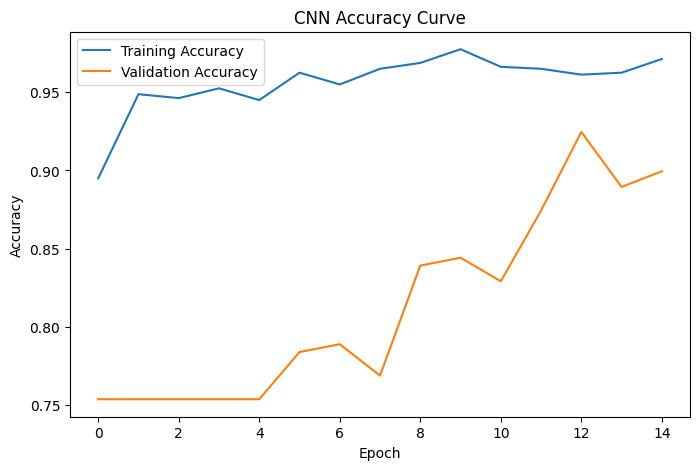

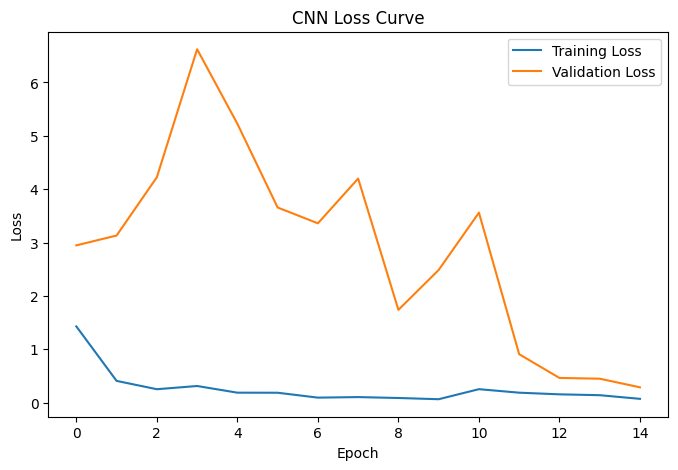

In [15]:
# ==========================================
# STEP 8: PLOT ACCURACY AND LOSS CURVES
# ==========================================

import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
# ==========================================
# STEP 9: IMPORT PRE-TRAINED MODEL
# ==========================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [17]:
# ==========================================
# STEP 10: LOAD MOBILENETV2 BASE MODEL
# ==========================================

# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze pre-trained layers
base_model.trainable = False

print("MobileNetV2 Loaded Successfully")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Loaded Successfully


In [18]:
# ==========================================
# STEP 11: BUILD TRANSFER LEARNING MODEL
# ==========================================

transfer_model = Sequential([

    # Normalize images
    tf.keras.layers.Rescaling(1./255),

    # Pre-trained MobileNetV2
    base_model,

    # Convert feature maps to vector
    GlobalAveragePooling2D(),

    # Dense layer
    Dense(128, activation='relu'),

    # Dropout layer
    Dropout(0.5),

    # Binary classification output
    Dense(1, activation='sigmoid')
])

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# ==========================================
# STEP 12: COMPILE TRANSFER MODEL
# ==========================================

transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Transfer Model Compiled")

Transfer Model Compiled


In [20]:
# ==========================================
# STEP 13: TRAIN TRANSFER LEARNING MODEL
# ==========================================

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8712 - loss: 0.3140 - val_accuracy: 0.9648 - val_loss: 0.1286
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9725 - loss: 0.0853 - val_accuracy: 0.9698 - val_loss: 0.0969
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9812 - loss: 0.0630 - val_accuracy: 0.9648 - val_loss: 0.1047
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 997ms/step - accuracy: 0.9887 - loss: 0.0401 - val_accuracy: 0.9648 - val_loss: 0.0950
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9925 - loss: 0.0347 - val_accuracy: 0.9648 - val_loss: 0.1119
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9937 - loss: 0.0270 - val_accuracy: 0.9648 - val_loss: 0.1360
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9962 - loss: 0.0199 - val_accuracy: 0.9598 - val_loss: 0.1529
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9975 - loss: 0.0144 - val_accuracy: 0.9698 - val_lo

In [21]:
# ==========================================
# STEP 14: EVALUATE CNN MODEL
# ==========================================

cnn_loss, cnn_accuracy = model.evaluate(val_ds)

print("CNN Accuracy:", cnn_accuracy)
print("CNN Loss:", cnn_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 449ms/step - accuracy: 0.8995 - loss: 0.2895
CNN Accuracy: 0.8994975090026855
CNN Loss: 0.2895105183124542


In [22]:
# ==========================================
# STEP 15: EVALUATE MOBILENETV2 MODEL
# ==========================================

mobilenet_loss, mobilenet_accuracy = transfer_model.evaluate(val_ds)

print("MobileNetV2 Accuracy:", mobilenet_accuracy)
print("MobileNetV2 Loss:", mobilenet_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 654ms/step - accuracy: 0.9698 - loss: 0.1230
MobileNetV2 Accuracy: 0.9698492288589478
MobileNetV2 Loss: 0.12296498566865921


In [23]:
# ==========================================
# STEP 16: PREPARE DATA FOR CONFUSION MATRIX
# ==========================================

import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = transfer_model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [24]:
# ==========================================
# STEP 17: CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       150
           1       0.98      0.90      0.94        49

    accuracy                           0.97       199
   macro avg       0.97      0.95      0.96       199
weighted avg       0.97      0.97      0.97       199



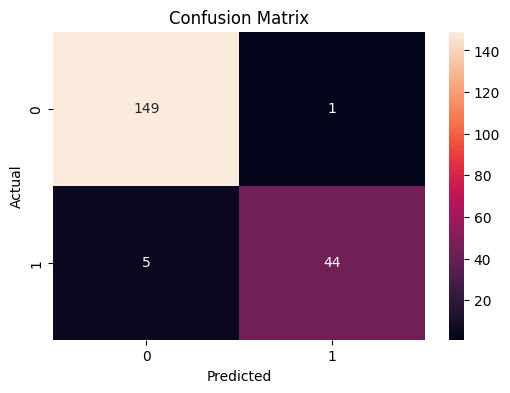

In [25]:
# ==========================================
# STEP 18: CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

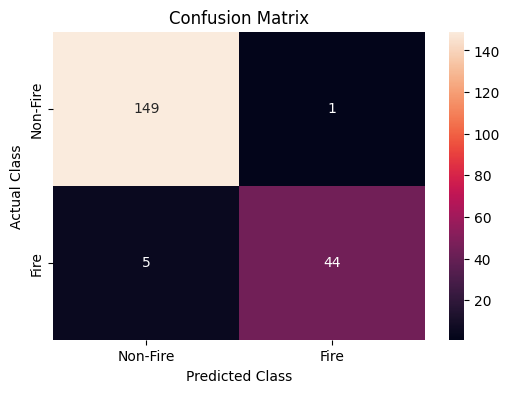

In [26]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Fire', 'Fire'],
    yticklabels=['Non-Fire', 'Fire']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [ ]:
# Results Summary

## Custom CNN
- Training Accuracy: 97.12%
- Validation Accuracy: 89.95%

## MobileNetV2
- Training Accuracy: 99.87%
- Validation Accuracy: 96.98%

## Conclusion
MobileNetV2 achieved better performance and generalization than the custom CNN model.